In [21]:
#Initial Imports
from astropy.io import fits
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
#Loading fits file and sectioning data into 32 amplifiers
from typing import Any


from matplotlib.pyplot import semilogx


filename = r"Y:\2D\20260406\iLocater_lab_20260406_0001_hxrgproc.fits"

def process_amps(filename):
    rows = []
    data = fits.getdata(filename)
    sections = np.split(data, 32, axis=1)
    
    #calculate summary stats for each amplifier
    for i, amp in enumerate[Any](sections):
        n = np.size(amp)
        total = np.sum(amp)
        mean = np.mean(amp)
        std = np.std(amp)
        sem = std / np.sqrt(n)
        var = std**2

        rows.append({
            "Amp #": i + 1,
            "Total Readout": total,
            "Total Readout Uncertainty": n * sem,
            "Mean Readout (Per Pixel)": mean,
            "Standard Deviation (Per Pixel)": std,
            "Standard Error in the Pixel Mean": sem,
            "Variance (Per Pixel)": var
        })

    #plot the stats
    df = pd.DataFrame(rows)
    x = df["Amp #"].to_numpy()
    y1 = df["Total Readout"].to_numpy()
    y1err = df["Total Readout Uncertainty"].to_numpy()
    y2 = df["Mean Readout (Per Pixel)"].to_numpy()
    y2err = df["Standard Error in the Pixel Mean"].to_numpy()

    #make subplots for stats both by amp and per pixel in each amp
    fig, axes = plt.subplots(2, 1, sharex = True, figsize = (7,8))

    #by amp plot
    axes[0].errorbar(x, y1, yerr = y1err,
    fmt="o", c="seagreen", capsize=4, markersize=3)
    axes[0].set_ylabel("Total Dark Current")

    #by pixel plot
    axes[1].errorbar(x, y2, yerr = y2err,
    fmt="o", c="salmon", capsize=4, markersize=3)
    axes[1].set_ylabel("Per Pixel Dark Current")
    axes[1].set_xlabel("Amp # (Left To Right)")

    plt.tight_layout()
    plt.show()

    #export stats as a CSV
    df.to_csv("Dark_Current_Stats_By_Amplifier.csv", index = False)



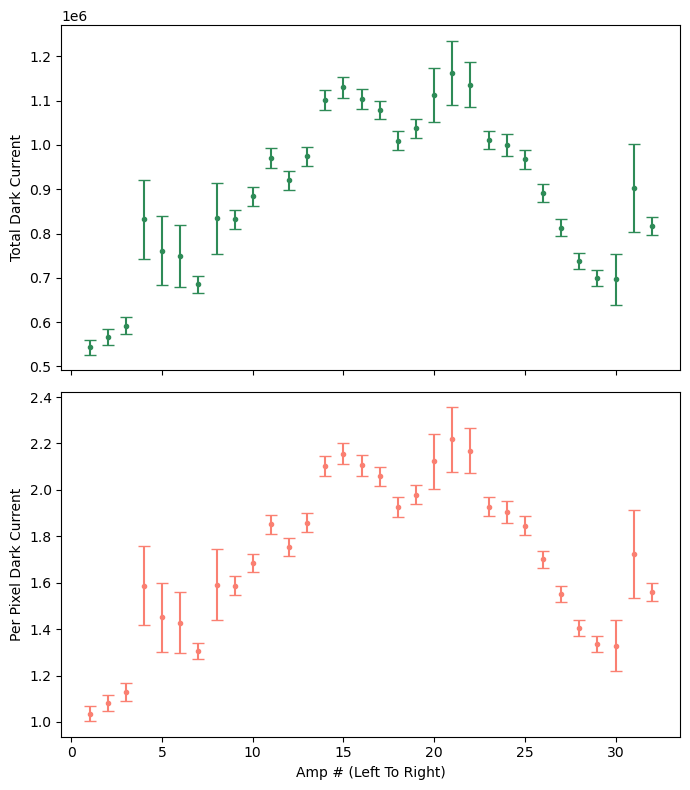

In [23]:
process_amps(filename)
